In [41]:
import numpy as np
import pandas as pd
import re 
import seaborn as sns 
import matplotlib.pyplot as plt 
import requests
from bs4 import BeautifulSoup
import warnings
warnings.filterwarnings("ignore")
import os

In [42]:
url = "https://www.ambitionbox.com/list-of-companies?"

In [43]:
response=requests.get(url)

In [44]:
response

<Response [403]>

In [45]:
requests_header={"content-type":"text/plain",
                "user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/141.0.0.0 Safari/537.36",
                "accept-encoding":"gzip, deflate, br, zstd"}

In [46]:
response=requests.get(url,headers=requests_header)

In [47]:
response

<Response [200]>

In [48]:
pagecontent=response.text

In [49]:
soup=BeautifulSoup(pagecontent)

In [78]:
companies = soup.find_all("div", class_="companyCardWrapper__companyPrimaryDetailsTopSection")
company_names=[]
for company in companies:
    company_names.append(re.findall(r"\w+",company.text))

print(company_names[0:10])

[['EPAM', 'Systems'], ['YASH', 'Technologies'], ['K12', 'Techno', 'Services'], ['Senco', 'Gold'], ['Ninjacart'], ['Novartis'], ['State', 'Street', 'Syntel'], ['IDBI', 'Bank'], ['SAP'], ['Aditya', 'Birla', 'Health', 'Insurance', 'Co']]


In [79]:
ratings=soup.find_all("div", class_="rating_text")
rates=[]
for i in ratings:
    rates.append(re.findall(r"\w+\W\w+",i.text))
print(rates[0:10])

[['3.7'], ['3.7'], ['3.7'], ['4.4'], ['3.8'], ['4.1'], ['3.7'], ['3.4'], ['4.1'], ['3.7']]


In [81]:
typeofcomp=soup.find_all("span", class_="companyCardWrapper__interLinking")
types=[]
for i in typeofcomp:
    if "|" in str(i):
        text = i.text.split("|")[0].strip()
        types.append(text)
    else:
        types.append("NA")

print(types[0:10])

['IT Services & Consulting', 'IT Services & Consulting', 'EdTech', 'Jewellery', 'Internet', 'Pharma', 'Financial Services', 'Banking', 'Software Product', 'Insurance']


In [82]:
locations=soup.find("span", class_="companyCardWrapper__interLinking")
locations

<span class="companyCardWrapper__interLinking">
								IT Services &amp; Consulting | Hyderabad +36 other locations
							</span>

In [83]:
locations=soup.find_all("span", class_="companyCardWrapper__interLinking")
location=[]
for i in locations:
    if "|" in str(i):
        text = i.text.split("|")[1].strip().split(" ")[0]
        location.append(text)
    else:
        location.append("NA")

print(location[0:20])

['Hyderabad', 'Hyderabad', 'Bengaluru', 'Kolkata', 'Bengaluru', 'Hyderabad', 'Mumbai', 'Mumbai', 'Bengaluru', 'Mumbai', 'Bengaluru', 'Bengaluru', 'Vadodara', 'Gurugram', 'Bengaluru', 'Pune', 'Gurugram', 'Pune', 'Pune', 'Mumbai']


In [84]:
counts=soup.find("span", class_="companyCardWrapper__ActionCount")
counts

<span class="companyCardWrapper__ActionCount">2k</span>

In [104]:
counts=soup.find_all("span", class_="companyCardWrapper__ActionCount")
reviews=[]
reviews_1=[]
salaries=[]
jobs=[]

for i in counts:
    reviews.append(i.text)
    reviews_1.extend(reviews[0::6])
    salaries.extend(reviews[1::6])
    jobs.extend(reviews[3::6])
    
print(reviews[0:10])
print("\n")
print(reviews_1[0:10])
print("\n")
print(salaries[0:10])
print("\n") 
print(jobs[0:10])


['2k', '22.7k', '632', '223', '132', '7', '2k', '16.2k', '171', '464']


['2k', '2k', '2k', '2k', '2k', '2k', '2k', '2k', '2k', '2k']


['22.7k', '22.7k', '22.7k', '22.7k', '22.7k', '22.7k', '22.7k', '16.2k', '22.7k', '16.2k']


['223', '223', '223', '223', '223', '223', '223', '464', '223', '464']


# Web scraping and store data inot dataframe url="https://www.ambitionbox.com/list-of-companies?"

In [ ]:
import requests
from bs4 import BeautifulSoup
import re

In [163]:

company_names=[]
rates=[]
rate_count = []
types=[]
location=[]
reviews_1=[]


us="https://www.ambitionbox.com/list-of-companies?"

for i in range(1,26):
    url=us+"page="+str(i)
    page = requests.get(url, headers=requests_header)
    soup=BeautifulSoup(page.text)
    
    # company name
    companies = soup.find_all("div", class_="companyCardWrapper__companyPrimaryDetailsTopSection")
    for company in companies:
        company_names.append(re.findall(r"\w+",company.text))
      
    #company rating
    ratings=soup.find_all("div", class_="rating_text")
    for i in ratings:
        rates.append(re.findall(r"\w+\W\w+",i.text))

    #Company Industry type 
    typeofcomp=soup.find_all("span", class_="companyCardWrapper__interLinking")
    for i in typeofcomp:
        if "|" in str(i):
            text = i.text.split("|")[0].strip()
            types.append(text)
        else:
            types.append("NA")
        
    # Company location   
    locations=soup.find_all("span", class_="companyCardWrapper__interLinking")
    for i in locations:
        if "|" in str(i):
            text = i.text.split("|")[1].strip().split(" ")[0]
            location.append(text)
        else:
            location.append("NA")
            
     # Comany reviews ,salary, jobs       
    counts=soup.find_all("span", class_="companyCardWrapper__ActionCount")
    reviews=[]
    for i in counts:
        reviews.append(i.text)
    reviews_1.extend(reviews[0::6])
    salaries.extend(reviews[1::6])
    jobs.extend(reviews[3::6])
 
    print(url)

https://www.ambitionbox.com/list-of-companies?page=1
https://www.ambitionbox.com/list-of-companies?page=2
https://www.ambitionbox.com/list-of-companies?page=3
https://www.ambitionbox.com/list-of-companies?page=4
https://www.ambitionbox.com/list-of-companies?page=5
https://www.ambitionbox.com/list-of-companies?page=6
https://www.ambitionbox.com/list-of-companies?page=7
https://www.ambitionbox.com/list-of-companies?page=8
https://www.ambitionbox.com/list-of-companies?page=9
https://www.ambitionbox.com/list-of-companies?page=10
https://www.ambitionbox.com/list-of-companies?page=11
https://www.ambitionbox.com/list-of-companies?page=12
https://www.ambitionbox.com/list-of-companies?page=13
https://www.ambitionbox.com/list-of-companies?page=14
https://www.ambitionbox.com/list-of-companies?page=15
https://www.ambitionbox.com/list-of-companies?page=16
https://www.ambitionbox.com/list-of-companies?page=17
https://www.ambitionbox.com/list-of-companies?page=18
https://www.ambitionbox.com/list-of-c

In [164]:
d={
    "company":company_names,
    "ratings":rates,
    "Industry":types,
    "location":location,
    "reviews": reviews_1,
    "salaries":salaries,
    "jobs":jobs,
   }

In [147]:
cmpy_df=pd.DataFrame(d)
cmpy_df

,company,ratings,Industry,location,reviews,salaries,jobs
0,[TCS],[3.3],IT Services & Consulting,Bengaluru,1.1L,9.9L,3.5k
1,[Accenture],[3.7],IT Services & Consulting,Bengaluru,72.4k,6.6L,28k
2,[Wipro],[3.6],IT Services & Consulting,Hyderabad,64.3k,4.8L,448
3,[Cognizant],[3.7],IT Services & Consulting,Hyderabad,60.6k,6L,472
4,[Capgemini],[3.7],IT Services & Consulting,Bengaluru,52.3k,4.8L,2.6k
...,...,...,...,...,...,...,...
495,"[Honeywell, Automation]",[3.7],Industrial Automation,Pune,1.9k,12.1k,--
496,"[Paisabazaar, com]",[3.4],Internet,Gurugram,1.9k,7k,40
497,[Schindler],[3.9],Industrial Machinery,Pune,1.9k,6.2k,69
498,"[Haier, Appliances, India]",[4.0],Consumer Electronics & Appliances,Pune,1.9k,7k,51


In [148]:
cmpy_df.shape

(500, 7)

In [149]:
cmpy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   company   500 non-null    object
 1   ratings   500 non-null    object
 2   Industry  500 non-null    object
 3   location  500 non-null    object
 4   reviews   500 non-null    object
 5   salaries  500 non-null    object
 6   jobs      500 non-null    object
dtypes: object(7)
memory usage: 27.5+ KB


In [150]:
cmpy_df["company"] = (cmpy_df["company"].astype(str).str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False).str.replace("'", "", regex=False)
    .str.strip())

In [151]:
cmpy_df.head()

,company,ratings,Industry,location,reviews,salaries,jobs
0,TCS,[3.3],IT Services & Consulting,Bengaluru,1.1L,9.9L,3.5k
1,Accenture,[3.7],IT Services & Consulting,Bengaluru,72.4k,6.6L,28k
2,Wipro,[3.6],IT Services & Consulting,Hyderabad,64.3k,4.8L,448
3,Cognizant,[3.7],IT Services & Consulting,Hyderabad,60.6k,6L,472
4,Capgemini,[3.7],IT Services & Consulting,Bengaluru,52.3k,4.8L,2.6k


In [152]:
#cmpy_df["ratings"] = cmpy_df["ratings"].str.strip("[]'").astype(float)
cmpy_df["ratings"] = (cmpy_df["ratings"].astype(str).str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False).str.replace("'", "", regex=False)
    .str.strip())

In [153]:
cmpy_df.head()

,company,ratings,Industry,location,reviews,salaries,jobs
0,TCS,3.3,IT Services & Consulting,Bengaluru,1.1L,9.9L,3.5k
1,Accenture,3.7,IT Services & Consulting,Bengaluru,72.4k,6.6L,28k
2,Wipro,3.6,IT Services & Consulting,Hyderabad,64.3k,4.8L,448
3,Cognizant,3.7,IT Services & Consulting,Hyderabad,60.6k,6L,472
4,Capgemini,3.7,IT Services & Consulting,Bengaluru,52.3k,4.8L,2.6k


In [154]:
def convert_to_number(x):
    if pd.isna(x):
        return None
    x = str(x).lower().replace(",", "")
    if "l" in x: 
        return float(x.replace("l", "")) * 100000
    elif "k" in x:  
        return float(x.replace("k", "")) * 1000
    else:
        try:
            return float(x)
        except:
            return None

for col in ["ratings","salaries", "reviews", "jobs"]:
    cmpy_df[col] = cmpy_df[col].apply(convert_to_number)

In [155]:
cmpy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   company   500 non-null    object 
 1   ratings   500 non-null    float64
 2   Industry  500 non-null    object 
 3   location  500 non-null    object 
 4   reviews   500 non-null    float64
 5   salaries  500 non-null    float64
 6   jobs      440 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


In [156]:
cmpy_df.head()

,company,ratings,Industry,location,reviews,salaries,jobs
0,TCS,3.3,IT Services & Consulting,Bengaluru,110000.0,990000.0,3500.0
1,Accenture,3.7,IT Services & Consulting,Bengaluru,72400.0,660000.0,28000.0
2,Wipro,3.6,IT Services & Consulting,Hyderabad,64300.0,480000.0,448.0
3,Cognizant,3.7,IT Services & Consulting,Hyderabad,60600.0,600000.0,472.0
4,Capgemini,3.7,IT Services & Consulting,Bengaluru,52300.0,480000.0,2600.0


In [157]:
cmpy_df.isnull().sum()

company      0
ratings      0
Industry     0
location     0
reviews      0
salaries     0
jobs        60
dtype: int64

In [158]:
cmpy_df['jobs'] = cmpy_df['jobs'].fillna(0)

In [159]:
cmpy_df.isnull().sum()

company     0
ratings     0
Industry    0
location    0
reviews     0
salaries    0
jobs        0
dtype: int64

In [160]:
cmpy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   company   500 non-null    object 
 1   ratings   500 non-null    float64
 2   Industry  500 non-null    object 
 3   location  500 non-null    object 
 4   reviews   500 non-null    float64
 5   salaries  500 non-null    float64
 6   jobs      500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


In [161]:
cmpy_df

,company,ratings,Industry,location,reviews,salaries,jobs
0,TCS,3.3,IT Services & Consulting,Bengaluru,110000.0,990000.0,3500.0
1,Accenture,3.7,IT Services & Consulting,Bengaluru,72400.0,660000.0,28000.0
2,Wipro,3.6,IT Services & Consulting,Hyderabad,64300.0,480000.0,448.0
3,Cognizant,3.7,IT Services & Consulting,Hyderabad,60600.0,600000.0,472.0
4,Capgemini,3.7,IT Services & Consulting,Bengaluru,52300.0,480000.0,2600.0
...,...,...,...,...,...,...,...
495,"Honeywell, Automation",3.7,Industrial Automation,Pune,1900.0,12100.0,0.0
496,"Paisabazaar, com",3.4,Internet,Gurugram,1900.0,7000.0,40.0
497,Schindler,3.9,Industrial Machinery,Pune,1900.0,6200.0,69.0
498,"Haier, Appliances, India",4.0,Consumer Electronics & Appliances,Pune,1900.0,7000.0,51.0


# convert clean datafram into csv csv_name: Ambition_job.csv

In [162]:
# 2. Define the folder path and file name
folder_name = '../dataset'
file_name = 'Ambition_job_output.csv'
full_path = os.path.join(folder_name, file_name)

# 3. Create the directory if it does not exist
# os.makedirs creates all necessary intermediate directories
os.makedirs(folder_name, exist_ok=True)

# 4. Save the DataFrame to the CSV file within the created folder
cmpy_df.to_csv(full_path, index=False)

# data analysis and visualization

In [172]:
# Web page input top 10 Industry,location,rating

In [171]:
cmpy_df["Industry"].value_counts().head(10)

IT Services & Consulting      70
Pharma                        30
Insurance                     27
Banking                       26
Internet                      24
BPO                           23
Financial Services            23
NBFC                          22
Automobile                    20
Engineering & Construction    17
Name: Industry, dtype: int64

In [170]:
cmpy_df["ratings"].value_counts().head(10)

3.9    80
4.0    69
3.8    65
3.6    52
4.1    48
3.7    48
3.5    34
4.2    28
3.4    22
3.3    17
Name: ratings, dtype: int64

In [169]:
cmpy_df["location"].value_counts().head(10)

Bengaluru    112
Mumbai       103
Pune          56
Chennai       43
Hyderabad     42
Gurugram      32
New           30
Noida         21
Kolkata        9
Ahmedabad      7
Name: location, dtype: int64

In [173]:
highestratings= cmpy_df.groupby("company")["ratings"].mean().sort_values(ascending=False).head(10)
print(highestratings)

company
Marpu, Foundation                              4.9
Indian, Army                                   4.7
Kogta, Financial, India, Limited               4.7
Indian, Air, Force                             4.6
iEnergizer                                     4.6
Muthoot, FinCorp                               4.6
Cloudnine, Hospital                            4.5
GAO, Tek                                       4.5
Sahrudaya, Healthcare, Medicover, Hospitals    4.4
Indian, Oil, Corporation                       4.4
Name: ratings, dtype: float64


In [174]:
most_reviewed= cmpy_df.groupby("company")["reviews"].sum().sort_values(ascending=False).head(10)
print(most_reviewed)

company
TCS               110000.0
Accenture          72400.0
Wipro              64300.0
Cognizant          60600.0
Capgemini          52300.0
HDFC, Bank         51500.0
Infosys            48100.0
ICICI, Bank        45400.0
HCLTech            45300.0
Tech, Mahindra     42800.0
Name: reviews, dtype: float64


In [175]:
avg_salary = cmpy_df.groupby("company")["salaries"].mean().sort_values(ascending=False).head(10)
print(avg_salary)

company
TCS               990000.0
Accenture         660000.0
Cognizant         600000.0
Infosys           520000.0
Capgemini         480000.0
Wipro             480000.0
HCLTech           380000.0
Tech, Mahindra    280000.0
Deloitte          250000.0
Genpact           230000.0
Name: salaries, dtype: float64


In [176]:
avg_salary_loc = cmpy_df.groupby("location")["salaries"].mean().sort_values(ascending=False)
print(avg_salary_loc.head())

location
Jamnagar      72900.000000
Hyderabad     58896.666667
Bengaluru     51974.107143
Jamshedpur    34400.000000
Ballari       31400.000000
Name: salaries, dtype: float64


In [177]:
most_jobs = cmpy_df.groupby("company")["jobs"].sum().sort_values(ascending=False).head(10)
print(most_jobs)

company
Accenture         28000.0
Bajaj, Finance     6700.0
Tata, Capital      4900.0
Ernst, Young       3800.0
TCS                3500.0
ABB                3100.0
Capgemini          2600.0
Infosys            2500.0
TP                 2100.0
Amazon             2100.0
Name: jobs, dtype: float64


In [178]:
cmpy_df.describe()

,ratings,reviews,salaries,jobs
count,500.000000,500.000000,500.000000,500.000000
mean,3.805800,5969.600000,28839.278000,231.980000
std,0.302671,9512.834693,75999.343922,1356.439544
min,2.700000,1900.000000,60.000000,0.000000
25%,3.600000,2400.000000,8400.000000,7.750000
50%,3.800000,3300.000000,12550.000000,40.000000
75%,4.000000,5300.000000,22725.000000,116.250000
max,4.900000,110000.000000,990000.000000,28000.000000


In [179]:
cmpy_df['company'].value_counts()

Ecom, Express                           1
RMSI                                    1
Nokia, Networks                         1
Bajaj, General, Insurance, Limited      1
Haier, Appliances, India                1
                                       ..
Aditya, Birla, Health, Insurance, Co    1
Extramarks, Education                   1
IDFC, FIRST, Bharat                     1
Dalmia, Bharat, Cement                  1
Eureka, Forbes                          1
Name: company, Length: 500, dtype: int64

## Univariate Analysis

##### Numerical column

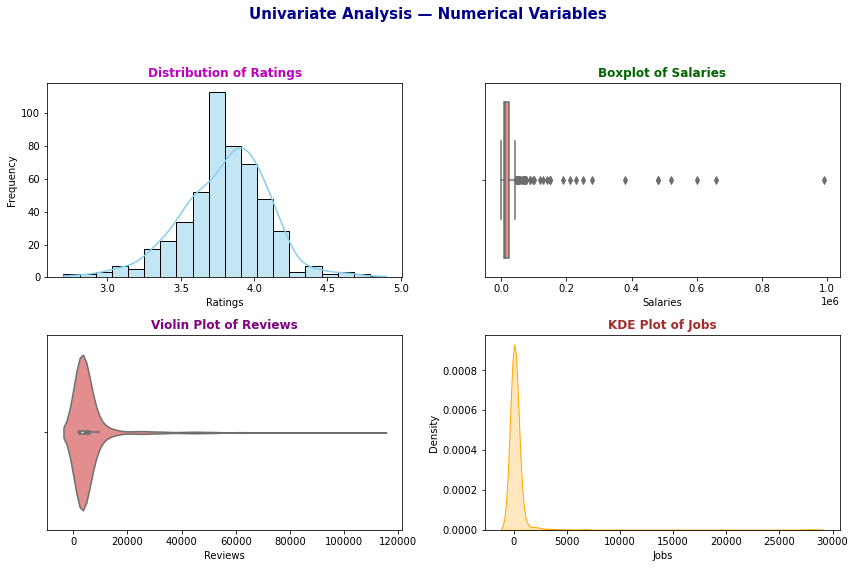

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create 2x2 grid layout ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plt.suptitle(
    "Univariate Analysis — Numerical Variables",
    color="darkblue",
    fontsize=15,
    fontweight="bold"
)

# 1️⃣ [0,0] — Histogram + KDE for Ratings
sns.histplot(cmpy_df['ratings'], bins=20, kde=True, color='skyblue', ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Ratings", fontsize=12, color='m', fontweight='bold')
axes[0, 0].set_xlabel("Ratings")
axes[0, 0].set_ylabel("Frequency")

# 2️⃣ [0,1] — Boxplot for Salaries
sns.boxplot(x=cmpy_df['salaries'], color='salmon', ax=axes[0, 1])
axes[0, 1].set_title("Boxplot of Salaries", fontsize=12, color='darkgreen', fontweight='bold')
axes[0, 1].set_xlabel("Salaries")
axes[0, 1].set_ylabel("")

# 3️⃣ [1,0] — Violin Plot for Reviews
sns.violinplot(x=cmpy_df['reviews'], color='lightcoral', ax=axes[1, 0])
axes[1, 0].set_title("Violin Plot of Reviews", fontsize=12, color='purple', fontweight='bold')
axes[1, 0].set_xlabel("Reviews")
axes[1, 0].set_ylabel("")

# 4️⃣ [1,1] — KDE Plot for Jobs
sns.kdeplot(cmpy_df['jobs'], fill=True, color='orange', ax=axes[1, 1])
axes[1, 1].set_title("KDE Plot of Jobs", fontsize=12, color='brown', fontweight='bold')
axes[1, 1].set_xlabel("Jobs")
axes[1, 1].set_ylabel("Density")

# --- Adjust layout and save ---
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(r"..\Dataset\Univariate_Numerical_Analysis.png", bbox_inches='tight')
plt.show();

##### categorical column

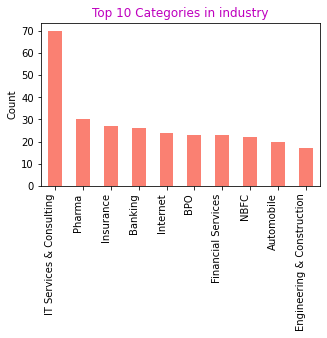

In [184]:
plt.figure(figsize=(5,3))
cmpy_df["Industry"].value_counts(dropna=False).head(10).plot(kind='bar', color='salmon')
plt.title(f"Top 10 Categories in industry",color='m')
plt.ylabel("Count")
plt.xticks(rotation=90, ha='right')
plt.tight_layout(rect=[0, 1, 1, 0.97])
plt.savefig(r"../Dataset/univariate cat3.png")
plt.show(); 

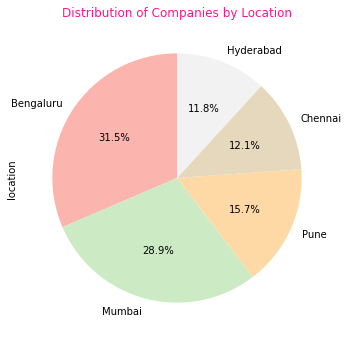

In [185]:
plt.figure(figsize=(5,5))
cmpy_df['location'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%', startangle=90, cmap='Pastel1')
plt.title("Distribution of Companies by Location",color='deeppink')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(r"../Dataset/univariate cat2.png")
plt.show();

## Bivariate Analysis

##### categorical vs numerical

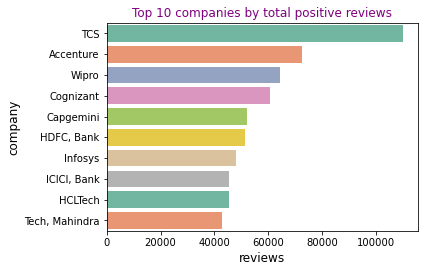

In [187]:
top_reviewed_companies = cmpy_df[['company', 'reviews']].sort_values(by='reviews', ascending=False).head(10)
plt.figure(figsize=(6,4))
sns.barplot(x='reviews', y='company', data=top_reviewed_companies, palette='Set2')
plt.title("Top 10 companies by total positive reviews",color="purple")
plt.ylabel("company", fontsize=12)
plt.xlabel("reviews", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(r"../Dataset/bivariate cat vs num2.png")
plt.show();  

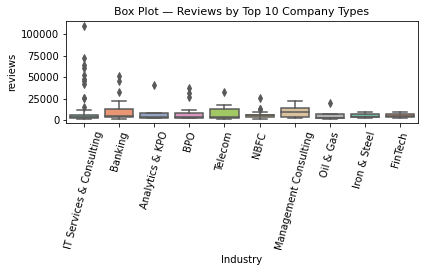

In [189]:
top10_types = cmpy_df.groupby('Industry')['reviews'].mean().sort_values(ascending=False).head(10).index
top10_df = cmpy_df[cmpy_df['Industry'].isin(top10_types)]
sns.boxplot(data=top10_df, x="Industry", y="reviews", palette="Set2")
plt.title("Box Plot — Reviews by Top 10 Company Types", fontsize=11)
plt.xticks(rotation=75)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(r"../Dataset/bivariate cat vs num1.png")
plt.show(); 